In [5]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [49]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
    
    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        
        out = Value(self.data+other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0*out.grad
            other.grad += 1.0*out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        
        out = Value(self.data*other.data, (self, other), '*')

        def _backward():
            self.grad += other.data*out.grad 
            other.grad += self.data*out.grad
        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self*other
    
    def __neg__(self):
        return self*-1
    def __sub__(self, other):
        return self + (-other)
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad    
        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float"
        out = Value(self.data**other, (self, ), f'**{other}')

        def _backward():
            self.grad  += other*self.data**(other-1) * out.grad 
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data*out.grad 
        out._backward = _backward
        return out

    def __truediv__(self, other):
        return self*other**-1

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            visited.add(v)
            for u in v._prev: 
                if u not in visited:
                    build_topo(u)
            topo.append(v)
        build_topo(self)
        
        self.grad = 1.0
        for v in reversed(topo):
            v._backward()

In [41]:
from graphviz import Digraph
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for to in v._prev:
                edges.add((to, v))
                build(to)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    nodes, edges = trace(root)
    for v in nodes:
        uid = str(id(v))
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (v.label, v.data, v.grad), shape='record')
        if v._op:
            dot.node(name=uid+v._op, label=v._op)
            dot.edge(uid+v._op, uid)
    for v, u in edges:
        dot.edge(str(id(v)), str(id(u)) + u._op)
    return dot

In [42]:
h = 0.000001
# inputs x1, x2
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
# weights w1, w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
# bias
b = Value(6.881373587, label = 'b')

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1+x2w2; x1w1x2w2.label = 'x1*w1+x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

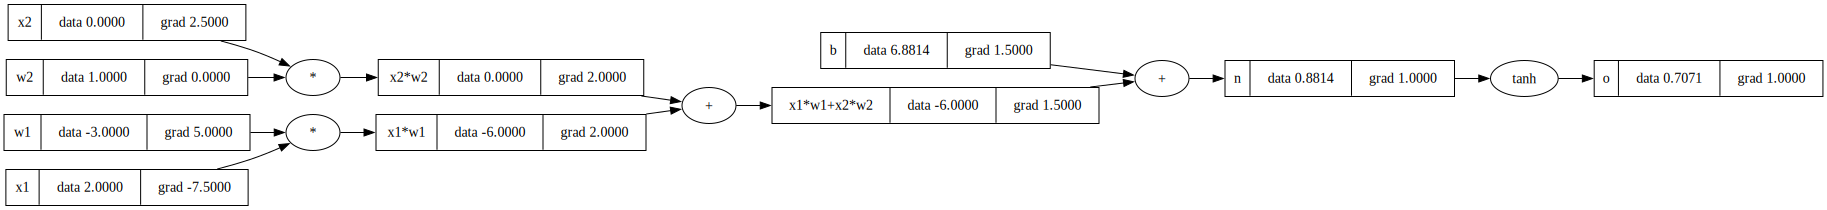

In [46]:
o.backward()
draw_dot(o)

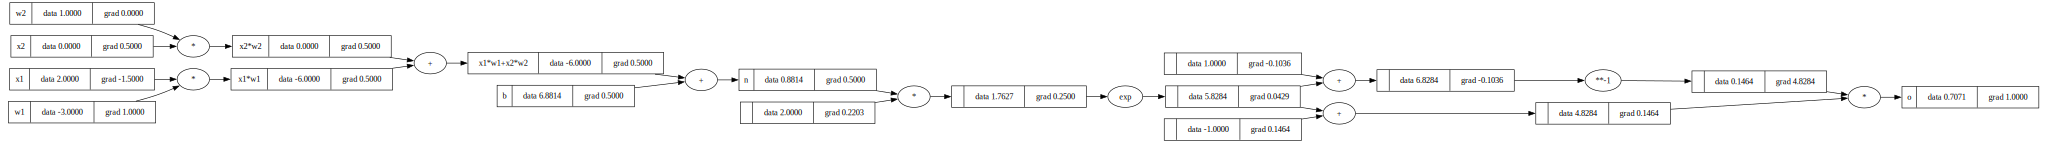

In [50]:
h = 0.000001
# inputs x1, x2
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
# weights w1, w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
# bias
b = Value(6.881373587, label = 'b')

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1+x2w2; x1w1x2w2.label = 'x1*w1+x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

e = (2*n).exp()
o = (e-1)/(e+1)
o.label = 'o'
o.backward()
draw_dot(o)